# 04 - Modeling
Training 4 model, evaluasi LOOCV, pilih model terbaik, simpan semua model.

In [2]:
import pandas as pd
import numpy as np
import joblib
import pickle
import json
import os
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Load data split
with open('../models/data_split.pkl', 'rb') as f:
    data = pickle.load(f)

X_train_s = data['X_train_scaled']
X_test_s  = data['X_test_scaled']
y_train   = data['y_train']
y_test    = data['y_test']
FEATURES  = data['features']

print('Data loaded!')
print('Training:', X_train_s.shape, '| Testing:', X_test_s.shape)


Data loaded!
Training: (27, 7) | Testing: (7, 7)


In [3]:
# Definisi model
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression':  Ridge(alpha=1.0),
    'Decision Tree':     DecisionTreeRegressor(max_depth=4, random_state=42),
    'Random Forest':     RandomForestRegressor(n_estimators=100, max_depth=4, random_state=42)
}

loo = LeaveOneOut()
results = {}

for name, model in models.items():
    print(f'Training: {name}...')

    # LOOCV — gunakan MAE dan RMSE saja (R2 tidak valid untuk LOO dengan data kecil)
    mae_scores  = -cross_val_score(model, X_train_s, y_train, cv=loo,
                                   scoring='neg_mean_absolute_error')
    rmse_scores = np.sqrt(-cross_val_score(model, X_train_s, y_train, cv=loo,
                                           scoring='neg_mean_squared_error'))

    # Fit full training, predict test
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)

    # Test R2 dihitung dari test set (bukan LOO) — lebih valid
    test_r2 = r2_score(y_test, y_pred)

    results[name] = {
        'cv_mae':   round(float(mae_scores.mean()), 4),
        'cv_rmse':  round(float(rmse_scores.mean()), 4),
        'cv_r2':    round(float(test_r2), 4),   # pakai test R2 sebagai acuan
        'test_mae':  round(float(mean_absolute_error(y_test, y_pred)), 4),
        'test_rmse': round(float(np.sqrt(mean_squared_error(y_test, y_pred))), 4),
        'test_r2':   round(float(test_r2), 4),
        'y_pred':   y_pred.tolist()
    }
    print(f'  CV MAE={mae_scores.mean():.4f} | CV RMSE={rmse_scores.mean():.4f} | Test R2={test_r2:.4f}')

print('\nSelesai!')


Training: Linear Regression...
  CV MAE=1.0940 | CV RMSE=1.0940 | Test R2=-0.4825
Training: Ridge Regression...
  CV MAE=1.1537 | CV RMSE=1.1537 | Test R2=-0.4781
Training: Decision Tree...
  CV MAE=1.2338 | CV RMSE=1.2338 | Test R2=-0.4755
Training: Random Forest...
  CV MAE=1.3050 | CV RMSE=1.3050 | Test R2=-0.2999

Selesai!


In [4]:
# Tabel perbandingan
rows = []
for name, r in results.items():
    rows.append({
        'Model':    name,
        'CV MAE':   r['cv_mae'],
        'CV RMSE':  r['cv_rmse'],
        'Test R2':  r['test_r2'],
        'Test MAE': r['test_mae'],
        'Test RMSE':r['test_rmse'],
    })
summary_df = pd.DataFrame(rows).set_index('Model')
print(summary_df.to_string())
summary_df


                   CV MAE  CV RMSE  Test R2  Test MAE  Test RMSE
Model                                                           
Linear Regression  1.0940   1.0940  -0.4825    2.2912     3.0205
Ridge Regression   1.1537   1.1537  -0.4781    1.8333     3.0161
Decision Tree      1.2338   1.2338  -0.4755    1.7106     3.0134
Random Forest      1.3050   1.3050  -0.2999    1.3623     2.8284


,CV MAE,CV RMSE,Test R2,Test MAE,Test RMSE
Model,,,,,
Linear Regression,1.0940,1.0940,-0.4825,2.2912,3.0205
Ridge Regression,1.1537,1.1537,-0.4781,1.8333,3.0161
Decision Tree,1.2338,1.2338,-0.4755,1.7106,3.0134
Random Forest,1.3050,1.3050,-0.2999,1.3623,2.8284


In [5]:
# Pilih model terbaik berdasarkan Test R2 tertinggi
best_name = max(results, key=lambda k: results[k]['test_r2'])
print(f'Model terbaik: {best_name}')
print(f'Test R2: {results[best_name]["test_r2"]} | CV MAE: {results[best_name]["cv_mae"]}')

# Retrain best model pada full training data dan simpan
best_model = models[best_name]
best_model.fit(X_train_s, y_train)
joblib.dump(best_model, '../models/best_model.pkl')
print('best_model.pkl disimpan!')


Model terbaik: Random Forest
Test R2: -0.2999 | CV MAE: 1.305
best_model.pkl disimpan!


In [6]:
# Simpan semua model individual
os.makedirs('../models', exist_ok=True)

for name, model in models.items():
    fname = name.lower().replace(' ', '_') + '.pkl'
    joblib.dump(model, f'../models/{fname}')
    print(f'Disimpan: {fname}')

print('\nSemua model berhasil disimpan!')


Disimpan: linear_regression.pkl
Disimpan: ridge_regression.pkl
Disimpan: decision_tree.pkl
Disimpan: random_forest.pkl

Semua model berhasil disimpan!


Feature Importances:
Inflation            0.379810
Exports              0.233345
Imports              0.183047
Exchange_Rate        0.087748
Population_Growth    0.061349
FDI                  0.044509
Unemployment         0.010192
dtype: float64


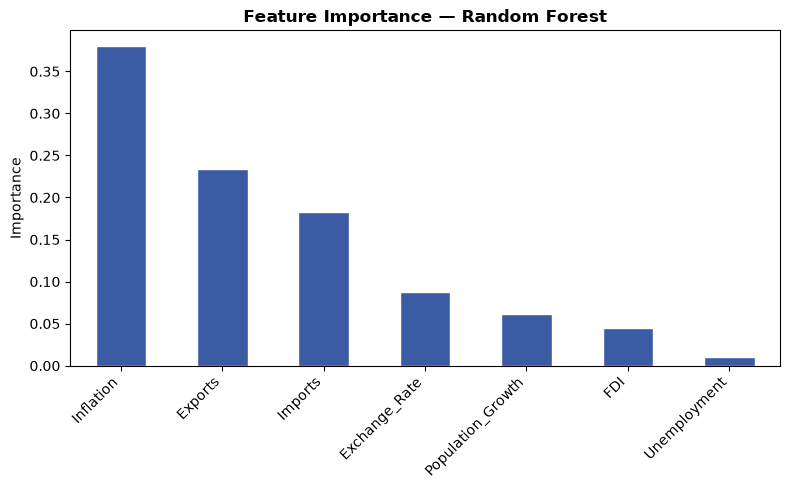

In [7]:
# Feature importance / koefisien
if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values(ascending=False)
    importance_dict = fi.to_dict()
    print('Feature Importances:')
elif hasattr(best_model, 'coef_'):
    fi = pd.Series(best_model.coef_, index=FEATURES).sort_values(ascending=False)
    importance_dict = fi.to_dict()
    print('Koefisien:')
print(fi)

# Plot
os.makedirs('../data/eda_outputs', exist_ok=True)
plt.figure(figsize=(8, 5))
fi.plot(kind='bar', color='#3B5BA5', edgecolor='white')
plt.title(f'Feature Importance — {best_name}', fontweight='bold')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../data/eda_outputs/feature_importance.png', dpi=150)
plt.show()


In [8]:
# Simpan model_report.json — sertakan y_pred semua model untuk grafik
model_report = {
    'best_model': best_name,
    'features': FEATURES,
    'results': results,   # ← y_pred per model IKUT tersimpan
    'feature_importance': importance_dict,
    'y_test': y_test.tolist(),
    'y_pred_best': results[best_name]['y_pred']
}

with open('../models/model_report.json', 'w') as f:
    json.dump(model_report, f, indent=2)

print('model_report.json disimpan!')
print(f'Best model: {best_name}')
print(f'Model tersimpan: {list(results.keys())}')


model_report.json disimpan!
Best model: Random Forest
Model tersimpan: ['Linear Regression', 'Ridge Regression', 'Decision Tree', 'Random Forest']


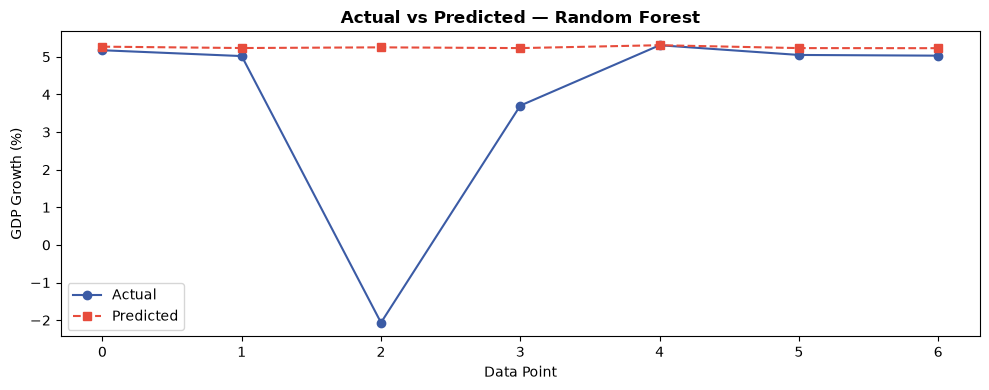

In [9]:
# Plot actual vs predicted — best model
y_pred_best = results[best_name]['y_pred']
plt.figure(figsize=(10, 4))
plt.plot(range(len(y_test)), list(y_test), marker='o', label='Actual', color='#3B5BA5')
plt.plot(range(len(y_pred_best)), y_pred_best, marker='s', label='Predicted',
         color='#E74C3C', linestyle='--')
plt.title(f'Actual vs Predicted — {best_name}', fontweight='bold')
plt.xlabel('Data Point')
plt.ylabel('GDP Growth (%)')
plt.legend()
plt.tight_layout()
plt.savefig('../data/eda_outputs/actual_vs_predicted.png', dpi=150)
plt.show()
